In [2]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill
import pandas as pd


from spock import FeatureClassifier
from spock import DeepRegressor
from spock import AnalyticalClassifier
from spock import CollisionMergerClassifier



In [3]:
tess_offset =  2457000

In [4]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Load in samples

In [5]:
### get the posterior data
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
# file_name = '1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [6]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)

posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.22      0.43    157.16      1.03
 ecosw_scaled[1]      0.35      0.06      0.34      0.25      0.44    157.72      1.03
 esinw_scaled[0]      0.36      0.09      0.36      0.22      0.51    151.05      1.05
 esinw_scaled[1]      0.38      0.08      0.38      0.26      0.51    150.82      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    214.86      1.03
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    350.97      1.03
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    253.05      1.03
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01    195.19      1.03
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    181.14      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.53    234.54      1.05

Number of divergences: 30
{'ecc': (8, 100

In [7]:
good_chain_idxs = [0,1,2,3,4,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}

# Shape of samples
print({k: v.shape for k, v in samples.items()})


{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 39), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


In [8]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
# e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
# e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1./3.)) # [AU]

e_c = np.sqrt(ecosw_c**2 + esinw_c**2)
e_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_c))
times = Tc_d
ref_time = 0.0 # set to simulation start time

M_c = mean_anomaly(ref_time, omega_c, e_c, Tc_c, P_c)
M_d = mean_anomaly(ref_time, omega_d, e_d, Tc_d, P_d)

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = np.full_like(omega_c, np.radians(value_Omega_c))
value_Omega_d = 0 # [deg]
Omega_d = np.full_like(omega_d, np.radians(value_Omega_d))

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + M_c
lambda_d = omega_d + Omega_d + M_d

# Set fixed inclination (e.g. edge-on)
inc_c = [0.]  * len(a_c)# [np.pi / 2] * len(a_c)
inc_d = [0.] * len(a_d)# [np.pi / 2] * len(a_d)

print(a_c)
print(m_c)
print(np.array(Omega_c))

[0.17053477 0.17053477 0.17053476 ... 0.17053413 0.17053482 0.1705335 ]
[1.32594778e-05 1.32760388e-05 1.31379475e-05 ... 1.42283043e-05
 1.88686045e-05 1.86341822e-05]
[0. 0. 0. ... 0. 0. 0.]


In [9]:
r_apo_c = a_c * (1 + e_c)
r_peri_d = a_d * (1 - e_d)
initially_crossed=[]
for i in range(len(r_apo_c)):
    r_apo = r_apo_c[i]
    r_peri = r_peri_d[i]
    if r_peri < r_apo:
        initially_crossed.append(i)

print(f'Systems where initial posterior state has r_peri_d < r_apo_c: {len(initially_crossed)}')

Systems where initial posterior state has r_peri_d < r_apo_c: 7322


In [10]:
# Set parameters (fixed values from literature) Polanski, orell-miquel
from astropy.constants import M_jup, M_sun
mass_b = 0.0302 * (M_jup / M_sun)
a_b = 0.079
e_b = 0.0
omega_b = np.radians(90.)
Omega_b = 0.0 # assume 0
inc_b =0# np.pi / 2
Tc_b = 2458715.35572 - tess_offset
P_b = 8.8803232



mass_e = 0.3590 * (M_jup / M_sun)  # MJup to Msun
a_e = 0.400
e_e = 0.0
omega_e = np.radians(230.0)
Omega_e = 0.0  # Assume 0 for simplicity
inc_e = 0# np.pi / 2  # edge-on
Tc_e = 2459044.0 - tess_offset
P_e = 101.5

# Reference time = same as for other planets
# t_ref = times[i]  # or pick a fixed time like 2459000

M_e = mean_anomaly(np.median(Tc_d), omega_e, e_e, Tc_e, P_e)
M_b = mean_anomaly(np.median(Tc_d), omega_b, e_b, Tc_b, P_b)

pomega_b = omega_b + Omega_b
pomega_e = omega_e + Omega_e
lambda_b = omega_b + Omega_b + M_b
lambda_e = omega_e + Omega_e + M_e

In [11]:
n_draws = 1  # or whatever number feels fast enough
N_total = len(P_c)  # assuming all arrays are same length

# Choose `n_draws` unique random indices
random_indices = np.random.choice(N_total, size=n_draws, replace=False)
print(random_indices)
random_indices = [1]

[7396]


prob of stability over 1e10 orbits of b: 0.9730502963066101
prob of deep model stability: 0.547
expectation of log-normal: 4522758360.63478
median expected instability time: 11445512730.626808
Probability of regular (non-chaotic) motion: 0.8906428748833726
0.00048802118 0.99861753 0.0008945545
[{'draw': 1, 'params': {'m_c': Array(1.3276039e-05, dtype=float32), 'a_c': 0.17053477, 'e_c': 0.013744581, 'inc_c': 0.0, 'Omega_c': 0.0, 'omega_c': 2.431259, 'M_c': Array(2.980814, dtype=float32), 'm_d': Array(7.4741365e-06, dtype=float32), 'a_d': 0.20746182, 'e_d': 0.01302479, 'inc_d': 0.0, 'Omega_d': 0.0, 'omega_d': 2.4404688, 'M_d': Array(2.5146174, dtype=float32)}, 'stability_prob': 0.9730502963066101, 'dmodel_stability_prob': 0.547, 'instability': {'median': 11445512730.626808, 'lower': 22735510.10311149, 'upper': 239501593116.29523, 'expectation_log_normal': 4522758360.63478, 'samples': [37879440137.17371, 302314363.75791126, 84330887813.00131, 36290101475.37893, 10762564154.88087, 62131551

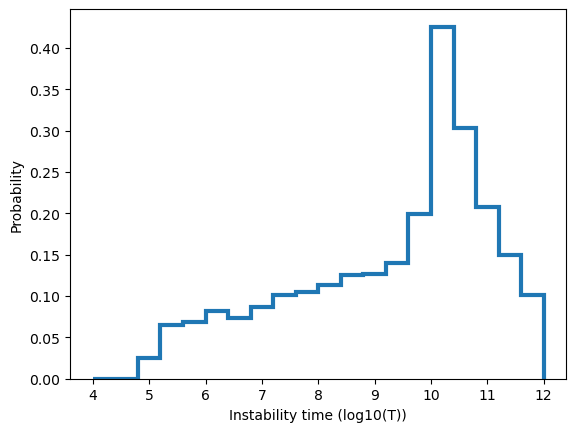

In [12]:
results = []

for i in random_indices:
    feature_model = FeatureClassifier()

    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun
    
    # Central star
    sim.add(m=m_star)
    
    # Planet b
    sim.add(m=mass_b,
            a=a_b,
            e=e_b,
            inc=inc_b,
            Omega=Omega_b,
            omega=omega_b,
            M=M_b)
    
    # Planet c
    sim.add(m=m_c[i],
                a=a_c[i],
                e= e_c[i],
                inc=inc_c[i],
                Omega=Omega_c[i],
                omega= omega_c[i],
                M=M_c[i])
    
    # Planet d
    sim.add(m=m_d[i],
                a=a_d[i],
                e= e_d[i],
                inc=inc_d[i],
                Omega=Omega_d[i],
                omega=omega_d[i],
                M=M_d[i])
    
    # Planet e
    sim.add(m=mass_e,
            a=a_e,
            e=e_e,
            inc=inc_e,
            Omega=Omega_e,
            omega=omega_e,
            M=M_e)
    
        
    sim.move_to_com()
    # scalar probability of stability over a billion orbits
    stability_orbit_prob = feature_model.predict_stable(sim, Nbodytmax = 1e10)
    print(f'prob of stability over 1e10 orbits of b: {stability_orbit_prob}')

    # estimate the median expected instability time 
    deep_model = DeepRegressor()
    deep_model_stability_prob = deep_model.predict_stable(sim)
    print(f'prob of deep model stability: {deep_model_stability_prob}')
    median, lower, upper, samples = deep_model.predict_instability_time(
        sim, samples=10000, return_samples=True, seed=0
    )
    expectation_log_norm = 10**np.average(np.log10(samples))
    print(f'expectation of log-normal: {10**np.average(np.log10(samples))}')  # Expectation of log-normal    
    print(f'median expected instability time: {median}')
    fig, ax = plt.subplots()
    ax.hist(np.log10(samples), density=True,
                histtype=u'step', bins=20,
                range=(4, 12), lw=3);
    
    plt.ylabel('Probability')
    plt.xlabel('Instability time (log10(T))')


    analytical_model = AnalyticalClassifier()
    analytical_stability_prob = analytical_model.predict_stable(sim)
    # 0 means confidently chaotic 
    print(f'Probability of regular (non-chaotic) motion: {analytical_stability_prob}')

    # predicting collisional outcome
    class_model = CollisionMergerClassifier()
    
    prob_12, prob_23, prob_13 = class_model.predict_collision_probs(sim)
    
    print(prob_12, prob_23, prob_13)


    ### save results 
    draw = i
    
    # collect results
    run_result = {
        "draw": i,
        "params": {
            "m_c": m_c[i],
            "a_c": a_c[i],
            "e_c": e_c[i],
            "inc_c": inc_c[i],
            "Omega_c": Omega_c[i],
            "omega_c": omega_c[i],
            "M_c": M_c[i],
            "m_d": m_d[i],
            "a_d": a_d[i],
            "e_d": e_d[i],
            "inc_d": inc_d[i],
            "Omega_d": Omega_d[i],
            "omega_d": omega_d[i],
            "M_d": M_d[i],
        },
        "stability_prob": float(stability_orbit_prob),
        "dmodel_stability_prob": float(deep_model_stability_prob),
        "instability": {
            "median": float(median),
            "lower": float(lower),
            "upper": float(upper),
            "expectation_log_normal": float(expectation_log_norm),
            # optional: store subset of samples (not all 10k if large)
            "samples": samples.tolist()[:100]  
        },
        "analytical_stability_prob": float(analytical_stability_prob),
        "collision_probs": {
            "prob_12": float(prob_12),
            "prob_23": float(prob_23),
            "prob_13": float(prob_13)
        }
    }

    results.append(run_result)

    
print(results)

In [13]:
df = pd.json_normalize(results)
print(df)

   draw  stability_prob  dmodel_stability_prob  analytical_stability_prob  \
0     1         0.97305                  0.547                   0.890643   

      params.m_c  params.a_c  params.e_c  params.inc_c  params.Omega_c  \
0  1.3276039e-05    0.170535    0.013745           0.0             0.0   

   params.omega_c  ... params.omega_d params.M_d  instability.median  \
0        2.431259  ...       2.440469  2.5146174        1.144551e+10   

   instability.lower  instability.upper  instability.expectation_log_normal  \
0       2.273551e+07       2.395016e+11                        4.522758e+09   

                                 instability.samples collision_probs.prob_12  \
0  [37879440137.17371, 302314363.75791126, 843308...                0.000488   

   collision_probs.prob_23  collision_probs.prob_13  
0                 0.998618                 0.000895  

[1 rows x 26 columns]


In [14]:
# df.to_csv("spock_simulation_results.csv", index=False)


In [15]:
# ext = '8_chain'
# df = pd.json_normalize(results)
# df.to_csv(f"spock_simulation_results_{ext}.csv", index=False)
# print(f'saved successfully to spock_simulation_results_{ext}.csv')


# Compare to Nbody

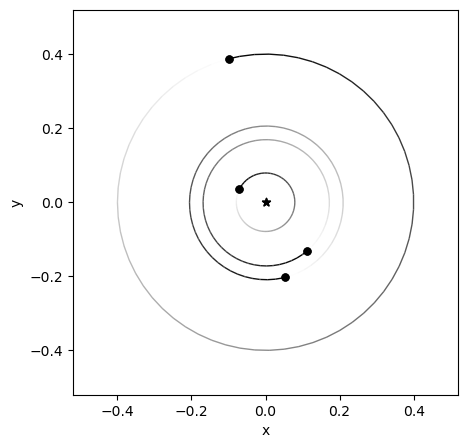

In [16]:
import rebound
%matplotlib inline

for i in random_indices:
    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun
    
    # Central star
    sim.add(m=m_star)
    
    # Planet b
    sim.add(m=mass_b,
            a=a_b,
            e=e_b,
            inc=inc_b,
            Omega=Omega_b,
            omega=omega_b,
            M=M_b)
    
    # Planet c
    sim.add(m=m_c[i],
                a=a_c[i],
                e= e_c[i],
                inc=inc_c[i],
                Omega=Omega_c[i],
                omega= omega_c[i],
                M=M_c[i])
    
    # Planet d
    sim.add(m=m_d[i],
                a=a_d[i],
                e= e_d[i],
                inc=inc_d[i],
                Omega=Omega_d[i],
                omega=omega_d[i],
                M=M_d[i])
    
    # Planet e
    sim.add(m=mass_e,
            a=a_e,
            e=e_e,
            inc=inc_e,
            Omega=Omega_e,
            omega=omega_e,
            M=M_e)
    
        
    sim.move_to_com()
    fig = rebound.OrbitPlot(sim)

In [17]:
from spock import FeatureClassifier
fmodel = FeatureClassifier()

from spock import NbodyRegressor
nbody = NbodyRegressor()

from spock import DeepRegressor
dmodel = DeepRegressor()

In [18]:
%%time
fmodel.predict_stable(sim)

CPU times: user 664 ms, sys: 1.67 ms, total: 666 ms
Wall time: 665 ms


0.9730503

In [19]:
%%time
dmodel.predict_stable(sim)

CPU times: user 5.31 s, sys: 7.75 s, total: 13.1 s
Wall time: 4.21 s


0.467

In [20]:
# %%time
# nbody.predict_stable(sim)

In [21]:
nbody.predict_stable(sim, tmax=1e4*sim.particles[2].P)

1

In [22]:
dmodel.predict_stable(sim, tmax=1e10*sim.particles[2].P)

0.156

In [23]:
# t_inst, lower, upper = nbody.predict_instability_time(sim) # instability time in time units used when setting up the Simulation
# print('Went unstable after {0:.1f} orbits of the inner planet. 68% confidence interval = [{1:.0f}, {2:.0f}] orbits.'.format(t_inst/sim.particles[1].P, lower/sim.particles[1].P, upper/sim.particles[1].P))

In [24]:
t_inst, lower, upper = dmodel.predict_instability_time(sim) # instability time in time units used when setting up the Simulation
print('Estimated instability time: {0:.1f} orbits of the inner planet. 68% confidence interval = [{1:.0f}, {2:.0f}] orbits.'.format(t_inst/sim.particles[1].P, lower/sim.particles[1].P, upper/sim.particles[1].P))

Estimated instability time: 1060421267.1 orbits of the inner planet. 68% confidence interval = [1868951, 23763831399] orbits.


In [25]:

# t_inst, lower, upper = nbody.predict_instability_time(sim, tmax=1e9*sim.particles[2].P)
# print(1e9*sim.particles[2].P)
# print(t_inst)

In [26]:
print(t_inst/sim.particles[2].P)

334351439.5702327


In [27]:
print(lower, upper)

16841729.627132103 214143693260.2621


# Grid of stability predictions

In [28]:
# i = 6087
# i = 3459
# i = 5308
# i = 5184
i=1
print(e_c[i])
print(e_d[i])

0.013744581
0.01302479


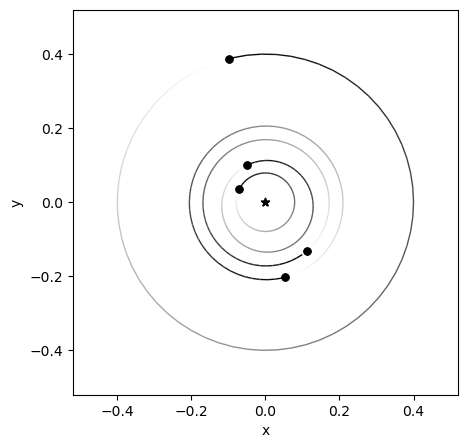

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from spock import FeatureClassifier
import rebound
%matplotlib inline

e=0.1
Pratio=1.3
mass = np.median(m_d)*2

sim = rebound.Simulation()
sim.units = ('AU', 'day', 'Msun')
sim.G = G_const  # Set your custom G if using AU/day²/Msun
    
# Central star
sim.add(m=m_star)
    
# Planet b
sim.add(m=mass_b,
            a=a_b,
            e=e_b,
            inc=inc_b,
            Omega=Omega_b,
            omega=omega_b,
            M=M_b)

# Planet ?
P_ = 17.7
a_ = np.array(((G_const*m_star*(P_)**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
M_ = mean_anomaly(np.median(Tc_d), 90, e, Tc_e, P_)
sim.add(m=mass,
            a=a_,
            e=e,
            inc=0,
            Omega=0,
            omega=90),
            #M=M_)
    
# Planet c
sim.add(m=m_c[i],
                a=a_c[i],
                e= e_c[i],
                inc=inc_c[i],
                Omega=Omega_c[i],
                omega= omega_c[i],
                M=M_c[i])
    
# Planet d
sim.add(m=m_d[i],
                a=a_d[i],
                e= e_d[i],
                inc=inc_d[i],
                Omega=Omega_d[i],
                omega=omega_d[i],
                M=M_d[i])
    
# Planet e
sim.add(m=mass_e,
            a=a_e,
            e=e_e,
            inc=inc_e,
            Omega=Omega_e,
            omega=omega_e,
            M=M_e)
rebound.OrbitPlot(sim)

In [30]:

def makesim(mass, e):
    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun
    
    # Central star
    sim.add(m=m_star)
    
    # Planet b
    sim.add(m=mass_b,
            a=a_b,
            e=e_b,
            inc=inc_b,
            Omega=Omega_b,
            omega=omega_b,
            M=M_b)

    # Planet ?
    P_ = 17.7
    a_ = np.array(((G_const*m_star*(P_)**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
    M_ = mean_anomaly(np.median(Tc_d), 90, e, Tc_e, P_)
    sim.add(m=mass,
            a=a_,
            e=e,
            inc=0,
            Omega=0,
            omega=90,
            M=M_)
    
    # Planet c
    sim.add(m=m_c[i],
                a=a_c[i],
                e= e_c[i],
                inc=inc_c[i],
                Omega=Omega_c[i],
                omega= omega_c[i],
                M=M_c[i])
    
    # Planet d
    sim.add(m=m_d[i],
                a=a_d[i],
                e= e_d[i],
                inc=inc_d[i],
                Omega=Omega_d[i],
                omega=omega_d[i],
                M=M_d[i])
    
    # Planet e
    sim.add(m=mass_e,
            a=a_e,
            e=e_e,
            inc=inc_e,
            Omega=Omega_e,
            omega=omega_e,
            M=M_e)

    return sim
    

In [31]:
# def makesim(Pratio, e):
#     sim = rebound.Simulation()
#     sim.add(m=1.)
#     sim.add(m=1.e-5, P=1, e=0)
#     sim.add(m=1.e-5, P=Pratio, e=e)
#     sim.add(m=1.e-5, P=Pratio**2, e=0)
#     return sim

In [79]:
# es = np.linspace(0, 0.1, 8)
# Pratios = np.linspace(1.15, 1.3, 20)
from astropy.constants import M_sun, M_earth
conversion = M_earth.value / M_sun.value
print(0.2*np.median(m_d) / conversion)
print(mass_b / conversion)
masses = np.linspace(0.2*np.median(m_d), mass_b, 20)
es = np.linspace(0, 0.2, 8)

print(masses)
print(es)

0.686541664203307
9.598417879159179
[2.06202058e-06 3.47079559e-06 4.87957061e-06 6.28834562e-06
 7.69712064e-06 9.10589565e-06 1.05146707e-05 1.19234457e-05
 1.33322207e-05 1.47409957e-05 1.61497707e-05 1.75585457e-05
 1.89673208e-05 2.03760958e-05 2.17848708e-05 2.31936458e-05
 2.46024208e-05 2.60111958e-05 2.74199709e-05 2.88287459e-05]
[0.         0.02857143 0.05714286 0.08571429 0.11428571 0.14285714
 0.17142857 0.2       ]


In [80]:
def get_sims(xlist, ylist):
    sims = []
    for y in ylist:
        for x in xlist:
            sims.append(makesim(x, y))
    return sims
            
def get_centered_grid(xlist, ylist, probs):  
    # assumes uniformly spaced values in x and y (can have different lengths)
    dx = xlist[1]-xlist[0]
    dy = ylist[1]-ylist[0]

    xgrid = [x - dx/2 for x in xlist] + [xlist[-1]+dx/2]
    ygrid = [y - dy/2 for y in ylist] + [ylist[-1]+dy/2]

    X, Y = np.meshgrid(xgrid, ygrid)
    Z = np.array(probs).reshape(len(ylist),len(xlist))

    return X,Y,Z

In [81]:
%%time
# model = FeatureClassifier()
model = DeepRegressor()
# sims = get_sims(Pratios, es)
sims = get_sims(masses, es)
probs = model.predict_stable(sims)


CPU times: user 51.1 s, sys: 33.2 s, total: 1min 24s
Wall time: 28.5 s


Text(0, 0.5, 'Eccentricity of 17.7 d Planet')

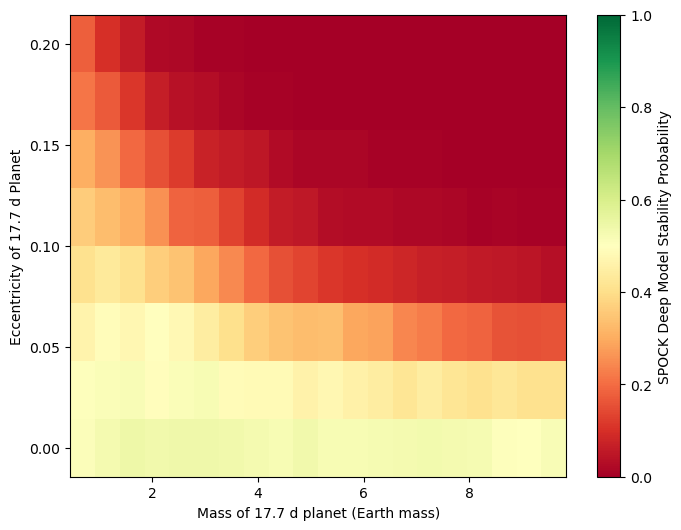

In [82]:
fig, ax = plt.subplots(figsize=(8,6))
from astropy.constants import M_sun, M_earth
conversion = M_earth.value / M_sun.value
masses_earth = masses / conversion
X,Y,Z = get_centered_grid(masses_earth, es, probs)
im = ax.pcolormesh(X, Y, Z, vmin=0, vmax=1, cmap="RdYlGn")

cb = plt.colorbar(im, ax=ax)
cb.set_label("SPOCK Deep Model Stability Probability")
ax.set_xlabel("Mass of 17.7 d planet (Earth mass)")
ax.set_ylabel("Eccentricity of 17.7 d Planet")

In [83]:
%%time
model = FeatureClassifier()
# model = DeepRegressor()
# sims = get_sims(Pratios, es)
sims = get_sims(masses, es)
probs = model.predict_stable(sims)


CPU times: user 2min 36s, sys: 1min 4s, total: 3min 41s
Wall time: 53.5 s


Text(0, 0.5, 'Eccentricity of 17.7 d Planet')

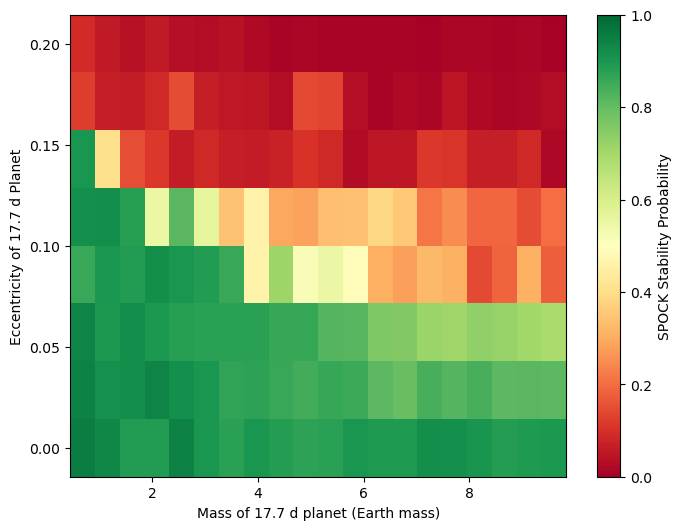

In [84]:
fig, ax = plt.subplots(figsize=(8,6))
from astropy.constants import M_sun, M_earth
conversion = M_earth.value / M_sun.value
masses_earth = masses / conversion
X,Y,Z = get_centered_grid(masses_earth, es, probs)
im = ax.pcolormesh(X, Y, Z, vmin=0, vmax=1, cmap="RdYlGn")

cb = plt.colorbar(im, ax=ax)
cb.set_label("SPOCK Stability Probability")
ax.set_xlabel("Mass of 17.7 d planet (Earth mass)")
ax.set_ylabel("Eccentricity of 17.7 d Planet")

In [85]:
%%time
model = AnalyticalClassifier()
# model = DeepRegressor()
# sims = get_sims(Pratios, es)
sims = get_sims(masses, es)
probs = model.predict_stable(sims)


CPU times: user 2.63 s, sys: 126 ms, total: 2.75 s
Wall time: 2.75 s


Text(0, 0.5, 'Eccentricity of 17.7 d Planet')

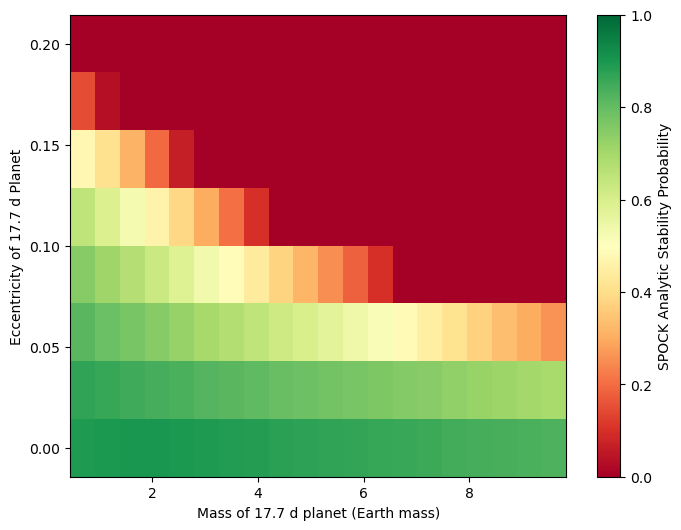

In [86]:
fig, ax = plt.subplots(figsize=(8,6))
from astropy.constants import M_sun, M_earth
conversion = M_earth.value / M_sun.value
masses_earth = masses / conversion
X,Y,Z = get_centered_grid(masses_earth, es, probs)
im = ax.pcolormesh(X, Y, Z, vmin=0, vmax=1, cmap="RdYlGn")

cb = plt.colorbar(im, ax=ax)
cb.set_label("SPOCK Analytic Stability Probability")
ax.set_xlabel("Mass of 17.7 d planet (Earth mass)")
ax.set_ylabel("Eccentricity of 17.7 d Planet")

# Stability results 

In [41]:
df_results = pd.read_csv("spock_simulation_results_8_chain.csv")
print(df_results)

      draw  stability_prob  dmodel_stability_prob  analytical_stability_prob  \
0        0        0.972993                  0.560                   0.893654   
1        1        0.973050                  0.515                   0.890643   
2        2        0.972993                  0.487                   0.893245   
3        3        0.973097                  0.564                   0.900077   
4        4        0.972162                  0.556                   0.904523   
...    ...             ...                    ...                        ...   
7995  7995        0.022101                  0.019                   0.000000   
7996  7996        0.017089                  0.004                   0.000000   
7997  7997        0.174494                  0.046                   0.000000   
7998  7998        0.866730                  0.172                   0.513969   
7999  7999        0.686348                  0.059                   0.043182   

      params.m_c  params.a_c  params.e_

In [50]:
feature_stability = df_results['stability_prob']
dmodel_stability = df_results['dmodel_stability_prob']
analytic_stability = df_results['analytical_stability_prob']

draw = df_results['draw']


In [51]:
print(dmodel_stability.max())
print(dmodel_stability.min())

0.661
0.0


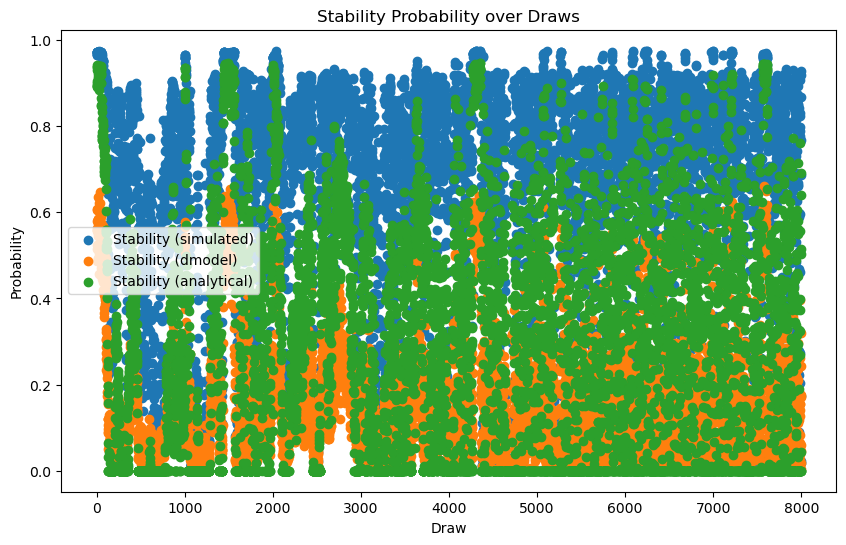

In [54]:
plt.figure(figsize=(10,6))
plt.scatter(draw, feature_stability, label="Stability (simulated)")
plt.scatter(draw, dmodel_stability, label="Stability (dmodel)")
plt.scatter(draw, analytic_stability, label="Stability (analytical)")
plt.xlabel("Draw")
plt.ylabel("Probability")
plt.title("Stability Probability over Draws")
plt.legend()
plt.show()


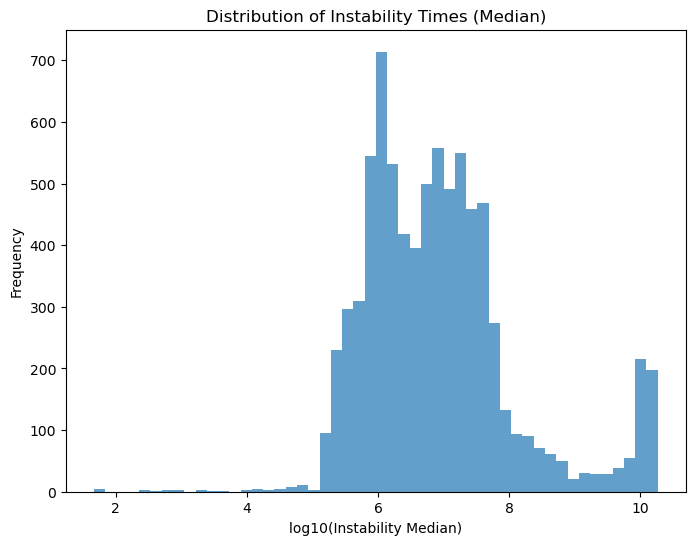

In [55]:

plt.figure(figsize=(8,6))
plt.hist(np.log10(df_results["instability.median"]), bins=50, alpha=0.7)
plt.xlabel("log10(Instability Median)")
plt.ylabel("Frequency")
plt.title("Distribution of Instability Times (Median)")
plt.show()

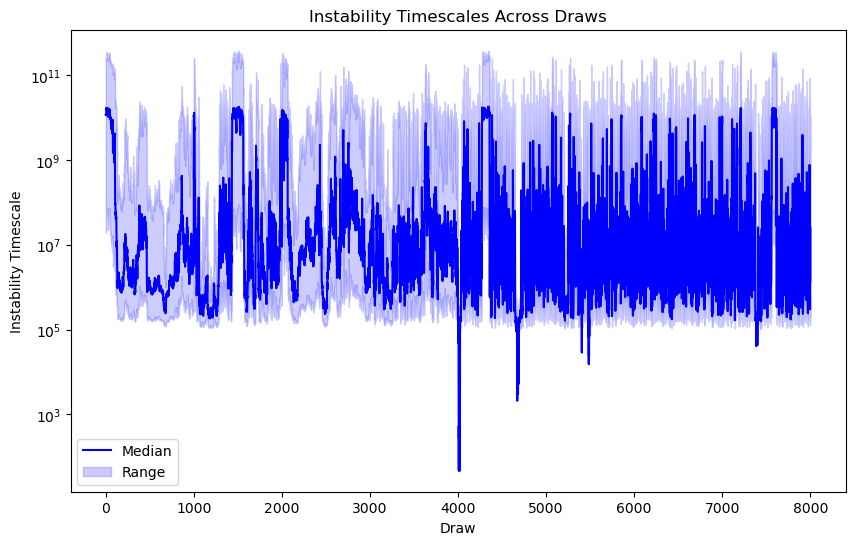

In [59]:
plt.figure(figsize=(10,6))
plt.plot(draw, df_results["instability.median"], label="Median", color="blue")
plt.fill_between(draw, df_results["instability.lower"], df_results["instability.upper"], 
                 alpha=0.2, label="Range", color="blue")
plt.yscale("log")
plt.xlabel("Draw")
plt.ylabel("Instability Timescale")
plt.title("Instability Timescales Across Draws")
plt.legend()
# plt.xlim(0,100)
plt.show()


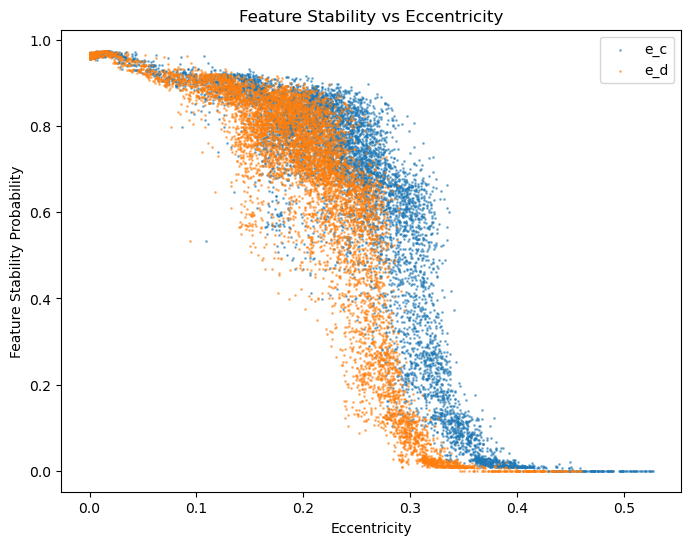

In [66]:
plt.figure(figsize=(8,6))
plt.scatter(df_results["params.e_c"], feature_stability, s=1, alpha=0.5, label='e_c')
plt.scatter(df_results["params.e_d"], feature_stability, s=1, alpha=0.5, label='e_d')

plt.xlabel("Eccentricity")
plt.ylabel("Feature Stability Probability")
plt.title("Feature Stability vs Eccentricity")
plt.legend()
plt.show()

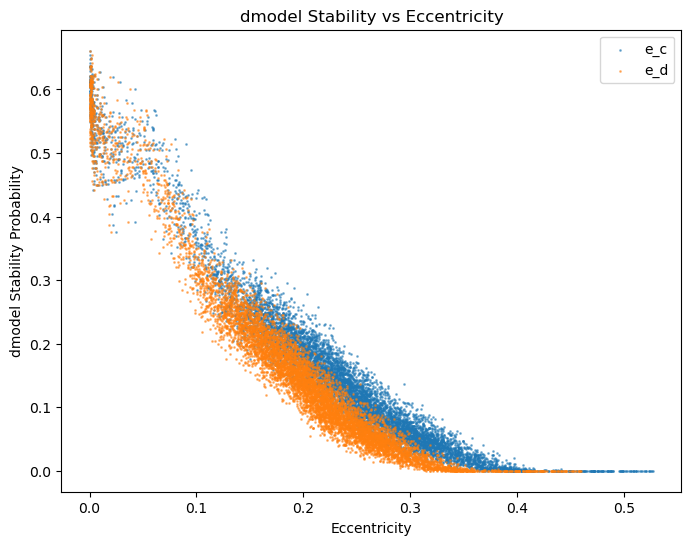

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(df_results["params.e_c"], dmodel_stability, s=1, alpha=0.5, label='e_c')
plt.scatter(df_results["params.e_d"], dmodel_stability, s=1, alpha=0.5, label='e_d')

plt.xlabel("Eccentricity")
plt.ylabel("dmodel Stability Probability")
plt.title("dmodel Stability vs Eccentricity")
plt.legend()
plt.show()

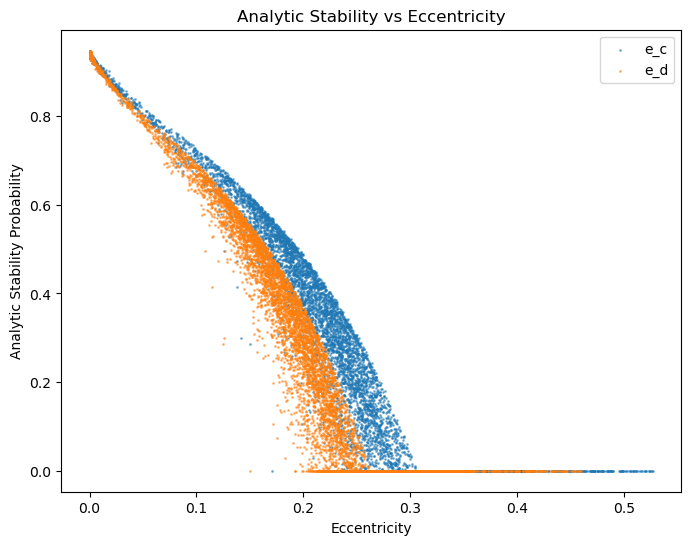

In [70]:
plt.figure(figsize=(8,6))
plt.scatter(df_results["params.e_c"], analytic_stability, s=1, alpha=0.5, label='e_c')
plt.scatter(df_results["params.e_d"], analytic_stability, s=1, alpha=0.5, label='e_d')

plt.xlabel("Eccentricity")
plt.ylabel("Analytic Stability Probability")
plt.title("Analytic Stability vs Eccentricity")
plt.legend()
plt.show()

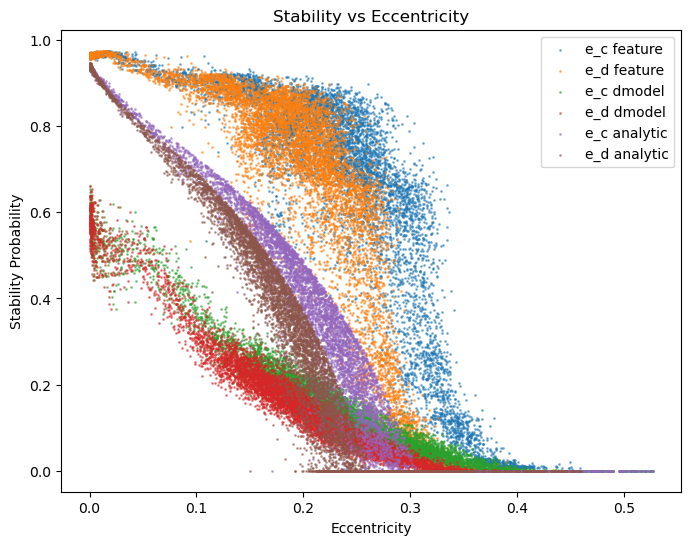

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(df_results["params.e_c"], feature_stability, s=1, alpha=0.5, label='e_c feature')
plt.scatter(df_results["params.e_d"], feature_stability, s=1, alpha=0.5, label='e_d feature')

plt.scatter(df_results["params.e_c"], dmodel_stability, s=1, alpha=0.5, label='e_c dmodel')
plt.scatter(df_results["params.e_d"], dmodel_stability, s=1, alpha=0.5, label='e_d dmodel')

plt.scatter(df_results["params.e_c"], analytic_stability, s=1, alpha=0.5, label='e_c analytic')
plt.scatter(df_results["params.e_d"], analytic_stability, s=1, alpha=0.5, label='e_d analytic')

plt.xlabel("Eccentricity")
plt.ylabel("Stability Probability")
plt.title("Stability vs Eccentricity")
plt.legend()
plt.show()